# テーマ5 ニューラルネットワークの基礎

## 目的
- ニューラルネットワークを「多数の重みを使って入力と出力の関係を学習するモデル」として理解する
- 入力層、隠れ層、出力層、損失関数、エポックの役割に慣れる
- Breast Cancer データセットで小さなニューラルネットワーク分類を行う
- 学習曲線から、学習の様子や過学習の兆候を読み取る

## 今日の成果物
- モデルの入力と出力の形を確認する
- epoch ごとの loss と accuracy を可視化する
- 訓練データとテストデータの差から、過学習の兆候を考察する

## 注意
- このテンプレートは PyTorch を使います
- 環境に PyTorch がない場合は、教員側で事前セットアップが必要です


## ニューラルネットワークの考え方

ニューラルネットワークは、入力を何段階かの変換に通して、最終的な予測を出すモデルです。

1つの層では、入力 $x$ に重み $W$ とバイアス $b$ を使って次のような計算をします。

$$
z = Wx + b
$$

そのあと、ReLU などの活性化関数を通します。

$$
ReLU(z) = \max(0, z)
$$

この「線形変換」と「非線形変換」を組み合わせることで、単純な直線だけでは表しにくい関係も学習できるようになります。


### Step 0: ライブラリを読み込む
PyTorch とデータ準備用のライブラリを読み込みます。乱数を固定して、実行ごとの結果のぶれを小さくします。


In [1]:
# ===== Step 0: ライブラリ読み込み =====
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)


device = cpu


### Step 1: データを読み込む
Breast Cancer データセットを読み込みます。ニューラルネットワークに入れる前に、入力特徴量と正解ラベルを分けます。


In [2]:
# ===== Step 1: データ読み込み =====
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame.copy()

X = df[cancer.feature_names]
y = df['target']

print('入力の形 =', X.shape)
print('クラス名 =', list(cancer.target_names))
display(df.head())


入力の形 = (569, 30)
クラス名 = [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Step 2: 学習用データを作る
学習用とテスト用に分け、特徴量を標準化してから PyTorch の Tensor に変換します。表形式データは、画像と違って2次元の入力として扱います。


In [3]:
# ===== Step 2: 学習データ作成 =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

print('入力特徴量の数 =', X_train_tensor.shape[1])
print('train batch 数 =', len(train_loader))


入力特徴量の数 = 30
train batch 数 = 15


### Step 3: ニューラルネットワークを定義する
入力層、隠れ層、出力層を持つ小さなモデルを作ります。出力は2クラス分のスコアになり、損失関数で正解との差を計算します。


#### 解説: 出力と損失関数

このモデルの最後の層は、2クラス分のスコアを出します。スコアそのものは確率ではありませんが、`CrossEntropyLoss` は内部で softmax を使って、正解クラスのスコアが高くなるように学習します。

softmax は次のように表されます。

$$
p_k = \frac{e^{z_k}}{\sum_j e^{z_j}}
$$

正解クラスの確率が高いほど損失は小さくなります。


In [4]:
# ===== Step 3: モデル定義 =====
class SimpleNN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 2),
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN(input_size=X_train_tensor.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)


SimpleNN(
  (layers): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
)


In [5]:
# ===== 追加演習: 1件だけモデルに通して出力の形を見る =====
model.eval()
with torch.no_grad():
    sample_output = model(X_train_tensor[:1].to(device))
    sample_prob = torch.softmax(sample_output, dim=1)

print('出力スコア:', sample_output.cpu().numpy())
print('softmax後の確率:', sample_prob.cpu().numpy())
print('予測クラス:', sample_prob.argmax(dim=1).item())


出力スコア: [[-0.11683604 -0.09368586]]
softmax後の確率: [[0.4942127  0.50578725]]
予測クラス: 1


### Step 4: モデルを学習する
epoch ごとに訓練データで重みを更新し、訓練データとテストデータの loss と accuracy を記録します。


#### 解説: エポックと過学習

エポックとは、学習データ全体を何回使って学習したかを表す単位です。エポックを増やすと、訓練データへの当てはまりは良くなりやすいですが、テストデータでの性能が必ず良くなるとは限りません。

過学習の典型的な見え方:

- train loss は下がり続ける
- test loss は途中から下がらない、または上がる
- train accuracy と test accuracy の差が大きくなる

学習曲線は、モデルが「学べているか」「覚えすぎていないか」を見るための図です。


In [6]:
# ===== Step 4: 学習 =====
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * len(batch_X)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch_y.cpu().numpy())

    return total_loss / len(loader.dataset), accuracy_score(all_labels, all_preds)

history = []
epochs = 30

for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

    train_loss, train_acc = evaluate(train_loader)
    test_loss, test_acc = evaluate(test_loader)
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
    })

history_df = pd.DataFrame(history)
display(history_df.tail())


,epoch,train_loss,test_loss,train_accuracy,test_accuracy
25,26,0.003204,0.184413,1.0,0.947368
26,27,0.001938,0.213078,1.0,0.956140
27,28,0.001370,0.227075,1.0,0.956140
28,29,0.001168,0.245621,1.0,0.956140
29,30,0.000909,0.232118,1.0,0.956140


### Step 5: 学習曲線を確認する
loss が下がっているか、訓練データとテストデータの accuracy に差が出ていないかを確認します。差が大きくなる場合は、過学習の兆候かもしれません。


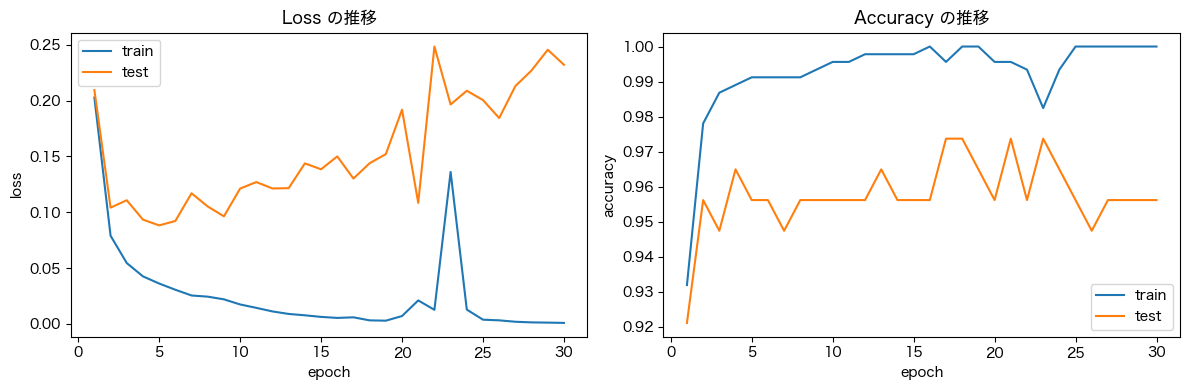

In [7]:
# ===== Step 5: 学習曲線 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[0].plot(history_df['epoch'], history_df['test_loss'], label='test')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss の推移')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], label='train')
axes[1].plot(history_df['epoch'], history_df['test_accuracy'], label='test')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy の推移')
axes[1].legend()

plt.tight_layout()
plt.show()


## 発展演習

時間があれば、次を試してください。

1. `epochs` を 10、30、80 に変えて学習曲線を比較する。
2. 隠れ層のユニット数 `16` や `8` を変える。
3. `lr=0.01` を `0.001` や `0.05` に変える。
4. train と test の差が大きくなったら、どの時点から過学習っぽいか説明する。

モデルを複雑にすれば必ず良くなるわけではありません。結果を図で確認しましょう。


## 振り返り
- 入力層、隠れ層、出力層は、このモデルのどこにありましたか。
- epoch が進むと loss はどのように変化しましたか。
- 訓練データとテストデータの accuracy に差はありましたか。
- CNN はニューラルネットワークの一種ですが、画像データ向けに何が追加されると思いますか。


## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: エポック数の影響 (簡単)

1. `epochs` を 50, 100, 200 と変えて学習させ、それぞれの最終的な訓練・テスト accuracy を比較してください。
2. エポック数を増やすと、必ず accuracy が良くなるとは限らないのはなぜですか。

```python
# ここにコードを書いてください
epochs_list = [50, 100, 200]

for num_epochs in epochs_list:
    # モデルを再初期化して学習
    # ...（テンプレートのコードを参照）
    print(f"Epochs={num_epochs}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")
```

### 演習2: 隠れ層のサイズ変更 (簡単)

1. 隠れ層のユニット数を 16, 32, 64 と変えて学習させ、結果を比較してください。
2. 隠れ層が大きすぎるとどのような問題が起こりそうですか。

```python
# ここにコードを書いてください
hidden_sizes = [16, 32, 64]

for hidden_size in hidden_sizes:
    # モデルの隠れ層サイズを変えて学習
    # ...（テンプレートのコードを参照）
    print(f"Hidden={hidden_size}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **ニューラルネットワークの基本構造** (200字程度)
   - 入力層、隠れ層、出力層がそれぞれ何をしているか、自分の言葉で説明してください。

2. **学習曲線の読み方** (200字程度)
   - 学習曲線（loss と accuracy の推移）から、どのような情報が読み取れますか。また、訓練データとテストデータの性能に差がある場合、それは何を意味しますか。

3. **ハイパーパラメータの影響** (300字程度)
   - 演習でエポック数や隠れ層のサイズを変えた結果をまとめてください。どのような傾向が見られましたか。

4. **過学習について** (200字程度)
   - ニューラルネットワークで過学習が起こりやすい理由を説明してください。また、過学習を防ぐ方法として何が考えられますか。

